RMSE: 0.0313
R2: 0.9991


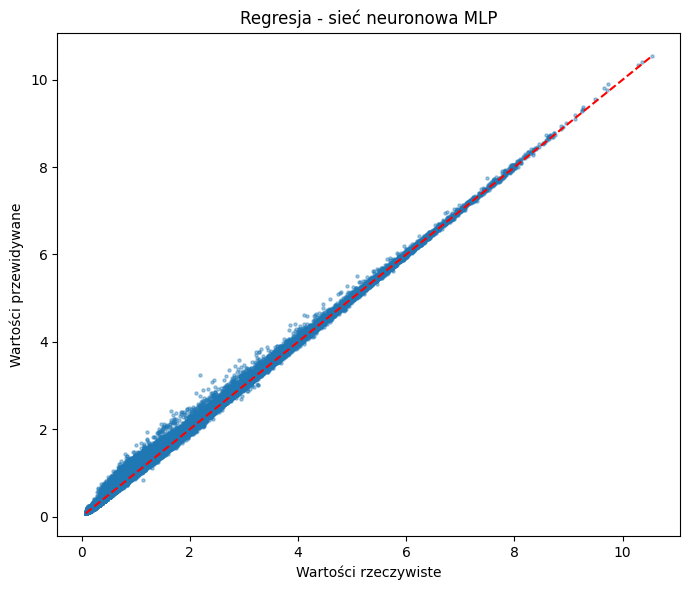

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Wczytanie i czyszczenie
df = pd.read_csv('household_power_consumption.txt', sep=';', na_values='?', low_memory=False)

cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

# 2. X i y
X = df[['Global_reactive_power', 'Voltage', 'Global_intensity',
        'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']]
y = df['Global_active_power']

# 3. Podział i skalowanie
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Sieć neuronowa do regresji
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42,
    early_stopping=True
)

model.fit(X_train, y_train)

# 5. Predykcja i ocena
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))

# 6. Wykres
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, s=5, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Wartości rzeczywiste")
plt.ylabel("Wartości przewidywane")
plt.title("Regresja - sieć neuronowa MLP")
plt.tight_layout()
plt.show()

# 7. Zapis wyników
wyniki = pd.DataFrame({
    'y_test': y_test.values,
    'y_pred': y_pred
})
wyniki.to_csv('wyniki_regresji.csv', index=False)